# Mineração de Dados — Projeto Final
## Avaliação dos Problemas de SQL da Plataforma Beecrowd como Instrumento de Ensino: uma Abordagem por Clusterização e Regras de Associação

**Programa:** PPGCO — Faculdade de Computação / UFU · **Disciplina:** Mineração de Dados

Este notebook aplica o fluxo completo de mineração de dados a um dataset de **51 problemas de SQL**
da plataforma Beecrowd (ex-URI Online Judge), anotados com **21 conceitos de SQL** e atributos de
identificação, popularidade e complexidade. Além da mineração exploratória, o objetivo pedagógico é
apoiar a **escolha de exercícios por tópico**, a partir da relação entre problemas e conceitos
exigidos na solução.

### Questões de pesquisa
- **QP1** — A plataforma Beecrowd, no recorte analisado, é um instrumento adequado para o ensino de SQL?
- **QP2** — O nível de dificuldade declarado é coerente com a complexidade técnica real dos problemas?
- **QP3** — Os problemas cobrem suficientemente os conceitos de SQL (básico → avançado) para as necessidades curriculares?

### Técnicas de Aprendizado de Máquina aplicadas
1. **Clusterização (K-Means)** — descoberta não supervisionada de grupos de problemas por perfil conceitual.
2. **Regras de associação (Apriori)** — combinações de conceitos que coexistem no mesmo SELECT (sequências de ensino).


## 0. Ambiente (Google Colab)


In [3]:
!pip -q install mlxtend

import os, warnings
warnings.filterwarnings("ignore")

CSV = "dataset_beecrowd_refinado-final.csv"

if os.path.exists(CSV):
    print("Dataset disponível: True")
else:
    print("Dataset disponível: False")
    print()
    print(f"O arquivo '{CSV}' ainda não está no ambiente.")
    print("Carregue-o pelo painel de Arquivos (ícone de pasta 📁 -> botão de upload ⬆)")
    print("e execute esta célula novamente.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dataset disponível: True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 1. Configuração e carga dos dados


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, spearmanr
from mlxtend.frequent_patterns import apriori, association_rules

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

CSV = "dataset_beecrowd_refinado-final.csv"
df = pd.read_csv(CSV)

_aux = [c for c in ["cluster_k2", "cluster_k3"] if c in df.columns]
if _aux:
    df = df.drop(columns=_aux)
    print("Colunas auxiliares removidas:", _aux)
print("Dimensões:", df.shape)
df.head(3)

Dimensões: (51, 36)


,problema_id,titulo,autor,url,enunciado,nivel,num_resolvidos,num_conceitos_total,faixa_conceitual,conceito_primario,conceitos_lista,usa_where,usa_order_by,usa_distinct,usa_like,usa_in,usa_between,usa_agregacao,usa_join,usa_group_by,usa_having,usa_subconsulta,usa_subconsulta_correlacionada,usa_union,usa_case,usa_funcao_data,usa_tratamento_null,usa_cast,usa_recursao,usa_funcao_janela,usa_pivot,usa_funcao_string,sql_entrada,sql_saida,complexidade_tecnica,discrepancia_nivel_complexidade
0,2602,Select Básico,Paulo R. Rodegheri,https://judge.beecrowd.com/pt/problems/view/2602,Sua empresa está fazendo um levantamento de qu...,4,41417,1,Básico,WHERE,WHERE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,--- URI Online Judge SQL\n--- Copyright URI On...,SELECT name from customers where state= 'RS';,1,1.067095
1,2603,Endereço dos Clientes,Paulo R. Rodegheri,https://judge.beecrowd.com/pt/problems/view/2603,A empresa fará um evento comemorando os 20 ano...,1,36554,1,Básico,WHERE,WHERE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,--- URI Online Judge SQL\n--- Copyright URI On...,"SELECT name,street from customers where city =...",1,-0.405558
2,2604,Menores que 10 ou Maiores que 100,Paulo R. Rodegheri,https://judge.beecrowd.com/pt/problems/view/2604,O setor financeiro da empresa precisa de um re...,2,32834,1,Básico,WHERE,WHERE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,--- URI Online Judge SQL\n--- Copyright URI On...,"SELECT id,name FROM products where price < 10 ...",1,0.085327


In [5]:
usa_cols = [c for c in df.columns if c.startswith("usa_")]
print(f"{len(usa_cols)} conceitos anotados")

ROTULO = {
    "usa_where": "WHERE", "usa_order_by": "ORDER BY", "usa_distinct": "DISTINCT",
    "usa_like": "LIKE", "usa_in": "IN", "usa_between": "BETWEEN",
    "usa_agregacao": "Agregação", "usa_join": "JOIN", "usa_group_by": "GROUP BY",
    "usa_having": "HAVING", "usa_subconsulta": "Subconsulta",
    "usa_subconsulta_correlacionada": "Subcons. correl.", "usa_union": "UNION",
    "usa_case": "CASE", "usa_funcao_data": "Função de data",
    "usa_tratamento_null": "Tratamento de NULL", "usa_cast": "CAST",
    "usa_recursao": "Recursão", "usa_funcao_janela": "Função de janela",
    "usa_pivot": "PIVOT", "usa_funcao_string": "Função de string",
}
def rotular(cols):
    return [ROTULO.get(c, c) for c in cols]

# --- Níveis técnicos dos conceitos (referência curricular) ---
# Usados tanto para a classificação em faixas quanto para a complexidade técnica.
CONCEITOS_BASICOS = ["usa_where", "usa_order_by", "usa_distinct", "usa_like",
                     "usa_in", "usa_between", "usa_funcao_string"]
CONCEITOS_INTERM  = ["usa_agregacao", "usa_join", "usa_group_by", "usa_having",
                     "usa_case", "usa_union", "usa_cast", "usa_funcao_data",
                     "usa_tratamento_null"]
CONCEITOS_AVANC   = ["usa_subconsulta", "usa_subconsulta_correlacionada",
                     "usa_recursao", "usa_funcao_janela", "usa_pivot"]
# mantém apenas os conceitos efetivamente presentes no dataset
CONCEITOS_BASICOS = [c for c in CONCEITOS_BASICOS if c in usa_cols]
CONCEITOS_INTERM  = [c for c in CONCEITOS_INTERM  if c in usa_cols]
CONCEITOS_AVANC   = [c for c in CONCEITOS_AVANC   if c in usa_cols]
assert len(CONCEITOS_BASICOS)+len(CONCEITOS_INTERM)+len(CONCEITOS_AVANC) == len(usa_cols), \
    "A partição em níveis não cobre todos os conceitos!"
print(f"Níveis: {len(CONCEITOS_BASICOS)} básicos, {len(CONCEITOS_INTERM)} intermediários, "
      f"{len(CONCEITOS_AVANC)} avançados")


21 conceitos anotados
Níveis: 7 básicos, 9 intermediários, 5 avançados


### 1.1 Complexidade técnica e discrepância

A **complexidade técnica** de cada problema é recalculada a partir da matriz problema–conceito
como uma soma ponderada dos conceitos por nível técnico:

$$CT = 1 \cdot b + 2 \cdot i + 3 \cdot a$$

onde $b$, $i$ e $a$ são os números de conceitos básicos, intermediários e avançados exigidos na
solução. A **discrepância** entre o nível declarado e a complexidade técnica usa as duas grandezas
padronizadas (escore $z$), para que fiquem na mesma escala:

$$D = z(\text{nível}) - z(CT)$$

Valores positivos indicam nível superestimado; negativos, subestimado.


In [6]:
# --- Complexidade técnica: CT = 1*b + 2*i + 3*a ---
b = df[CONCEITOS_BASICOS].sum(axis=1)
i = df[CONCEITOS_INTERM].sum(axis=1)
a = df[CONCEITOS_AVANC].sum(axis=1)

PESOS = (1, 2, 3)  # (básico, intermediário, avançado)
df["complexidade_tecnica"] = PESOS[0]*b + PESOS[1]*i + PESOS[2]*a

# --- Discrepância: D = z(nível) - z(CT) ---
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

df["discrepancia_nivel_complexidade"] = zscore(df["nivel"]) - zscore(df["complexidade_tecnica"])

print("Complexidade técnica:")
print(df["complexidade_tecnica"].describe().round(2).to_string())
print("\nDiscrepância  D = z(nível) - z(CT):")
print(df["discrepancia_nivel_complexidade"].describe().round(3).to_string())


Complexidade técnica:
count    51.00
mean      5.76
std       5.38
min       1.00
25%       2.50
50%       4.00
75%       6.00
max      21.00

Discrepância  D = z(nível) - z(CT):
count    51.000
mean      0.000
std       0.982
min      -3.595
25%      -0.406
50%       0.085
75%       0.692
max       1.674


## 2. Pré-processamento e verificação de qualidade


In [7]:
info = pd.DataFrame({"dtype": df.dtypes.astype(str), "n_nulos": df.isna().sum()})
print("Colunas com valores ausentes:")
print(info[info.n_nulos > 0] if info.n_nulos.sum() else "  (nenhuma)")

soma_flags = df[usa_cols].sum(axis=1)
inconsistentes = int((df["num_conceitos_total"] != soma_flags).sum())
orfaos = int((soma_flags == 0).sum())
print(f"\nLinhas inconsistentes (total != soma flags): {inconsistentes}")
print(f"Problemas sem nenhum conceito (órfãos): {orfaos}")
assert inconsistentes == 0 and orfaos == 0, "Falha de integridade no dataset!"
print("Integridade OK.")

Colunas com valores ausentes:
  (nenhuma)

Linhas inconsistentes (total != soma flags): 0
Problemas sem nenhum conceito (órfãos): 0
Integridade OK.


In [8]:
num_cols = ["nivel", "num_resolvidos", "num_conceitos_total",
            "complexidade_tecnica", "discrepancia_nivel_complexidade"]
df[num_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
nivel,51.0,3.647,2.057,1.000,2.000,3.000,5.000,9.000
num_resolvidos,51.0,10540.529,9846.373,50.000,2655.500,7175.000,14521.500,41417.000
num_conceitos_total,51.0,3.353,2.448,1.000,2.000,3.000,4.000,10.000
complexidade_tecnica,51.0,5.765,5.384,1.000,2.500,4.000,6.000,21.000
discrepancia_nivel_complexidade,51.0,0.000,0.982,-3.595,-0.406,0.085,0.692,1.674


## 3. Análise exploratória (EDA)


### 3.1 Cobertura conceitual — quantos problemas exercitam cada conceito? (QP3)


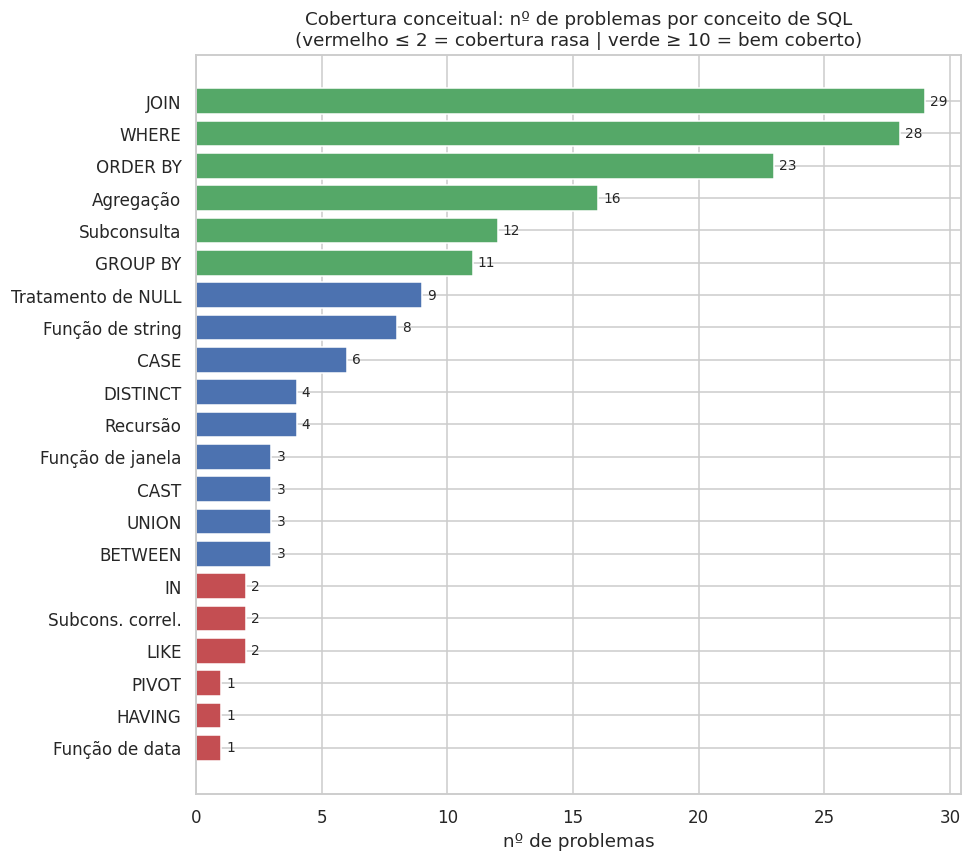

In [9]:
freq = df[usa_cols].sum().sort_values(ascending=True)
freq.index = rotular(freq.index)

plt.figure(figsize=(9, 8))
cores = ["#C44E52" if v <= 2 else "#55A868" if v >= 10 else "#4C72B0" for v in freq.values]
plt.barh(freq.index, freq.values, color=cores)
for i, v in enumerate(freq.values):
    plt.text(v + 0.2, i, str(int(v)), va="center", fontsize=9)
plt.title("Cobertura conceitual: nº de problemas por conceito de SQL\n"
          "(vermelho ≤ 2 = cobertura rasa | verde ≥ 10 = bem coberto)")
plt.xlabel("nº de problemas"); plt.tight_layout(); plt.show()

### 3.2 Distribuição dos conceitos por faixa conceitual (Figura 2)


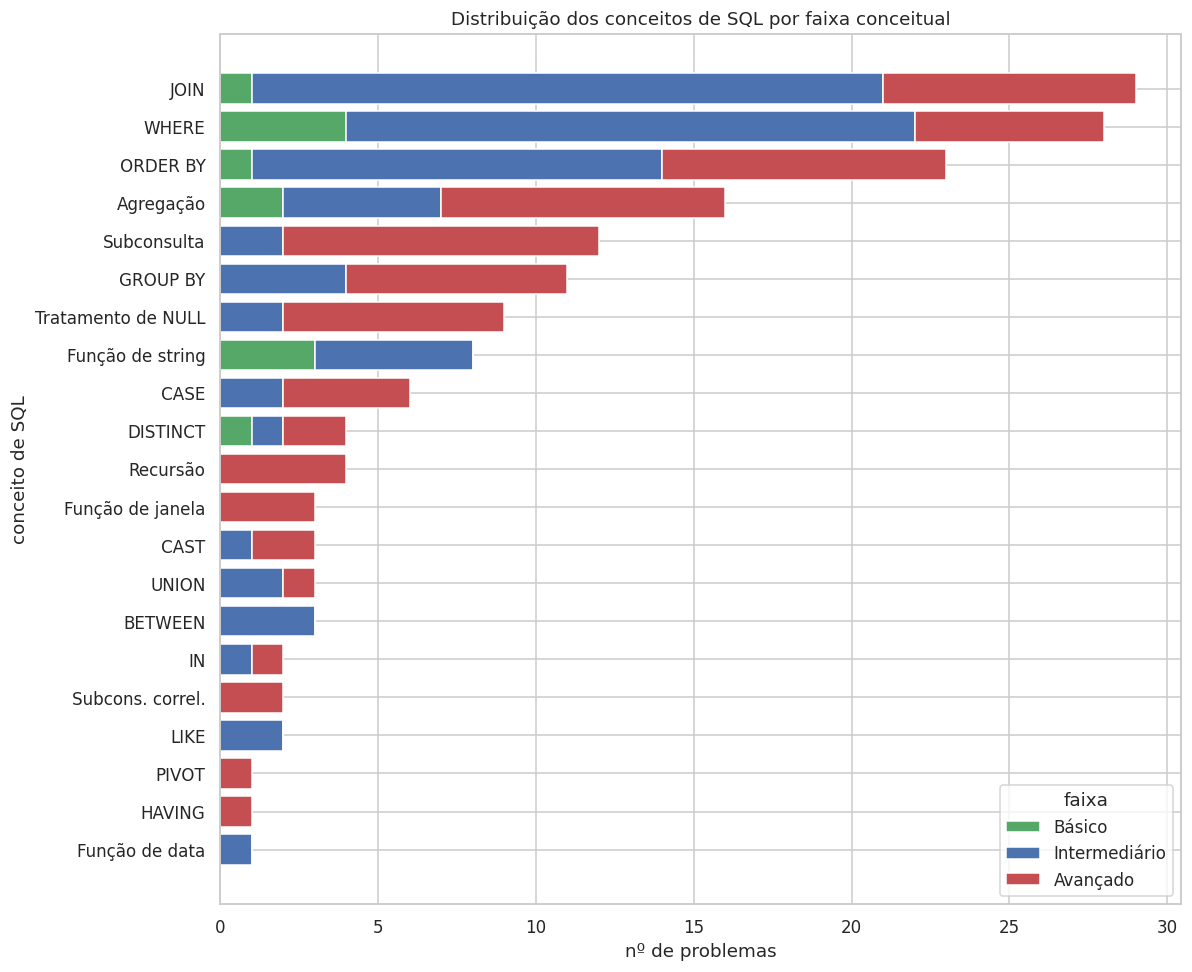

In [10]:
# Figura 2 — para cada conceito, quantos problemas o exercitam em cada faixa
ordem = ["Básico", "Intermediário", "Avançado"]
cores = {"Básico": "#55A868", "Intermediário": "#4C72B0", "Avançado": "#C44E52"}

# contagem conceito x faixa
dist = []
for c in usa_cols:
    linha = {"conceito": ROTULO.get(c, c)}
    for f in ordem:
        linha[f] = int(df.loc[df["faixa_conceitual"] == f, c].sum())
    dist.append(linha)
dist = pd.DataFrame(dist).set_index("conceito")
dist["_tot"] = dist.sum(axis=1)
dist = dist.sort_values("_tot", ascending=True).drop(columns="_tot")

fig, ax = plt.subplots(figsize=(11, 9))
esq = [0]*len(dist)
for f in ordem:
    ax.barh(dist.index, dist[f], left=esq, color=cores[f], label=f, edgecolor="white")
    esq = [e + v for e, v in zip(esq, dist[f])]
ax.set_xlabel("nº de problemas")
ax.set_ylabel("conceito de SQL")
ax.set_title("Distribuição dos conceitos de SQL por faixa conceitual")
ax.legend(title="faixa", loc="lower right")
plt.tight_layout(); plt.show()


### 3.3 Validação da classificação em faixas — Figuras 3 e 4


Coerência faixa × conceitos complexos:
  'Básico' que usam conceito avançado : 0  (esperado 0)
  'Avançado' sem conceito complexo    : 0  (esperado 0)
  Média de conceitos avançados por faixa:
faixa_conceitual
Básico           0.00
Intermediário    0.07
Avançado         2.00


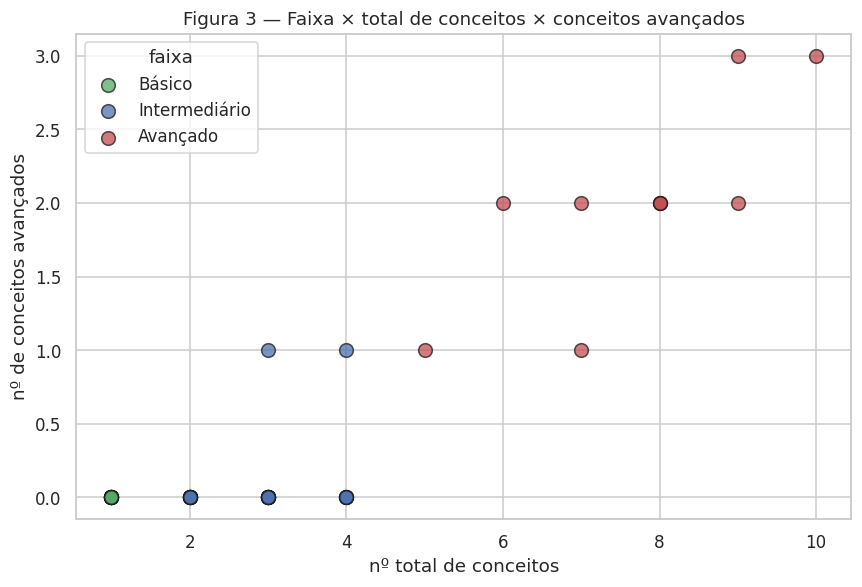

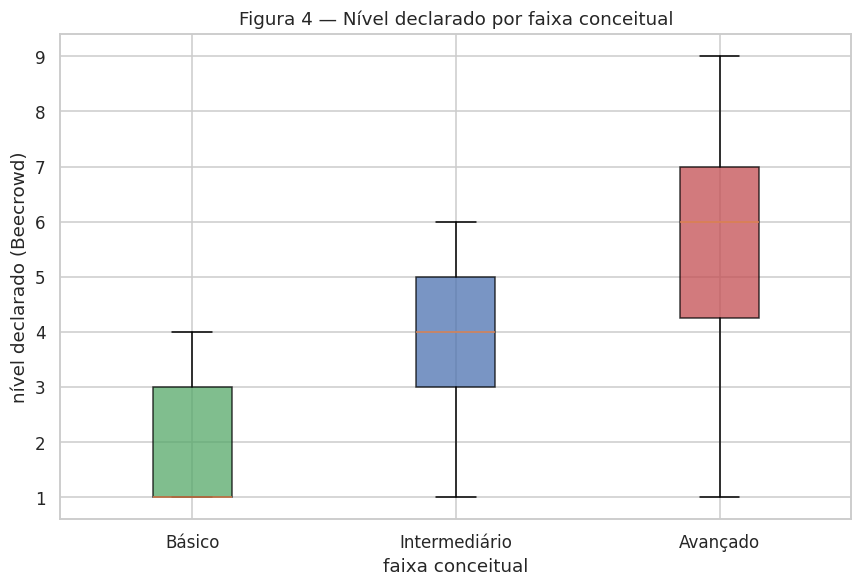

In [11]:
ordem = ["Básico", "Intermediário", "Avançado"]
AVANCADOS = ["usa_subconsulta", "usa_subconsulta_correlacionada",
             "usa_recursao", "usa_funcao_janela", "usa_pivot"]
AVANCADOS = [c for c in AVANCADOS if c in df.columns]
df["_n_avancados"] = df[AVANCADOS].sum(axis=1)

inconsist_basico = df[(df["faixa_conceitual"] == "Básico") & (df["_n_avancados"] > 0)]
inconsist_avanc  = df[(df["faixa_conceitual"] == "Avançado") & (df["_n_avancados"] == 0)]
print("Coerência faixa × conceitos complexos:")
print(f"  'Básico' que usam conceito avançado : {len(inconsist_basico)}  (esperado 0)")
print(f"  'Avançado' sem conceito complexo    : {len(inconsist_avanc)}  (esperado 0)")
print("  Média de conceitos avançados por faixa:")
print(df.groupby('faixa_conceitual')['_n_avancados'].mean().reindex(ordem).round(2).to_string())

cores = {"Básico": "#55A868", "Intermediário": "#4C72B0", "Avançado": "#C44E52"}

# --- Figura 3: faixa × total de conceitos × conceitos avançados ---
fig3, ax3 = plt.subplots(figsize=(8, 5.5))
for f in ordem:
    d = df[df["faixa_conceitual"] == f]
    ax3.scatter(d["num_conceitos_total"], d["_n_avancados"],
                label=f, color=cores[f], s=80, edgecolor="k", alpha=0.75)
ax3.set_xlabel("nº total de conceitos"); ax3.set_ylabel("nº de conceitos avançados")
ax3.set_title("Figura 3 — Faixa × total de conceitos × conceitos avançados")
ax3.legend(title="faixa")
plt.tight_layout(); plt.show()

# --- Figura 4: nível declarado por faixa conceitual ---
fig4, ax4 = plt.subplots(figsize=(8, 5.5))
dados = [df[df["faixa_conceitual"] == f]["nivel"] for f in ordem]
bp = ax4.boxplot(dados, tick_labels=ordem, patch_artist=True)
for patch, f in zip(bp["boxes"], ordem):
    patch.set_facecolor(cores[f]); patch.set_alpha(0.75)
ax4.set_ylabel("nível declarado (Beecrowd)"); ax4.set_xlabel("faixa conceitual")
ax4.set_title("Figura 4 — Nível declarado por faixa conceitual")
plt.tight_layout(); plt.show()

df.drop(columns=["_n_avancados"], inplace=True)


## 4. Demonstração visual PROBLEMA × CONCEITO


### 4.1 Matriz problema × conceito (heatmap)


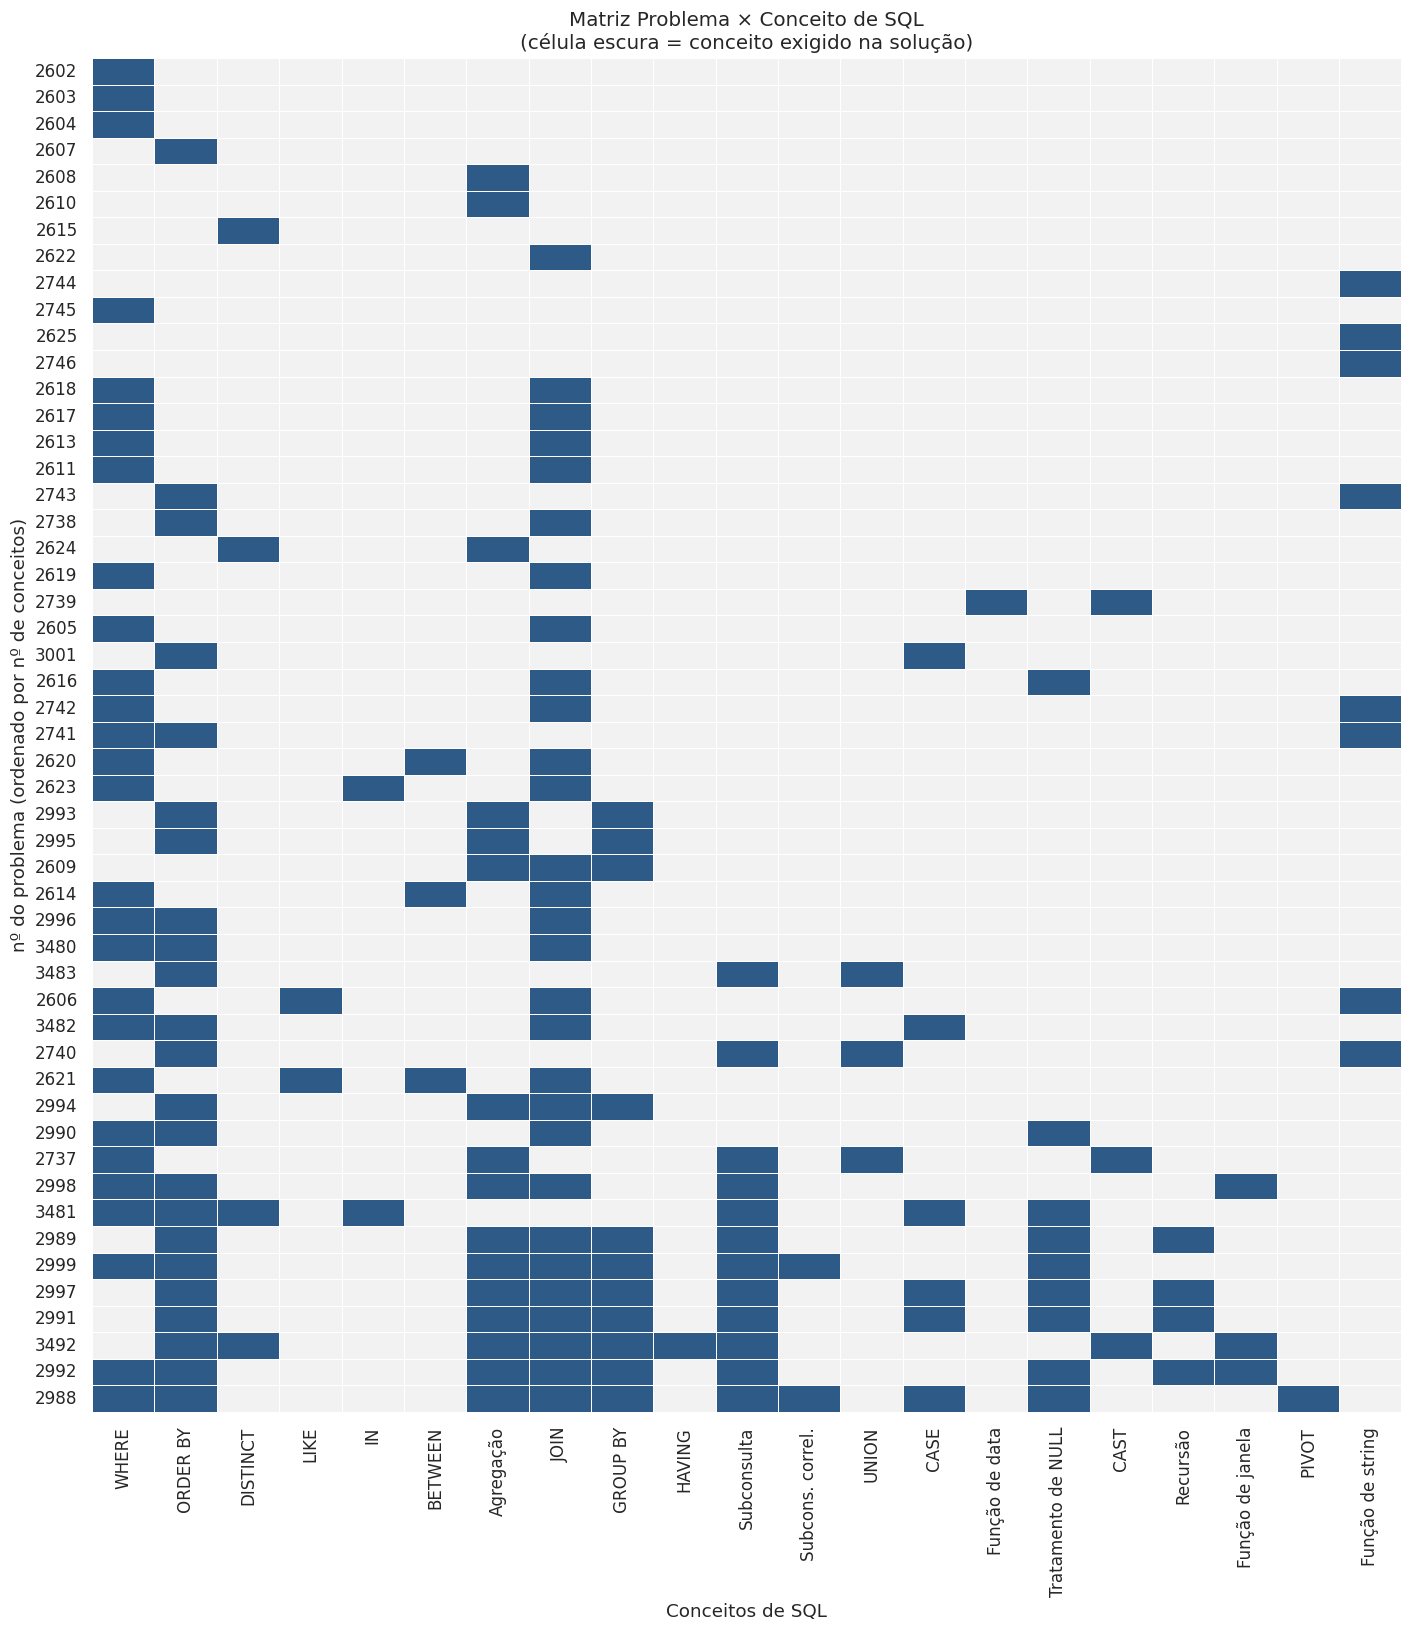

In [12]:
# Matriz problema × conceito — eixo Y = nº que identifica o problema (problema_id)
mat = df.sort_values("num_conceitos_total").set_index("problema_id")[usa_cols]
mat.columns = rotular(mat.columns)

plt.figure(figsize=(13, 15))
sns.heatmap(mat, cmap=["#F2F2F2", "#2E5A87"], cbar=False, linewidths=0.4, linecolor="white")
plt.title("Matriz Problema × Conceito de SQL\n(célula escura = conceito exigido na solução)", fontsize=13)
plt.xlabel("Conceitos de SQL"); plt.ylabel("nº do problema (ordenado por nº de conceitos)")
plt.tight_layout(); plt.show()


### 4.2 Co-ocorrência de conceitos — quais conceitos aparecem juntos no mesmo SELECT?


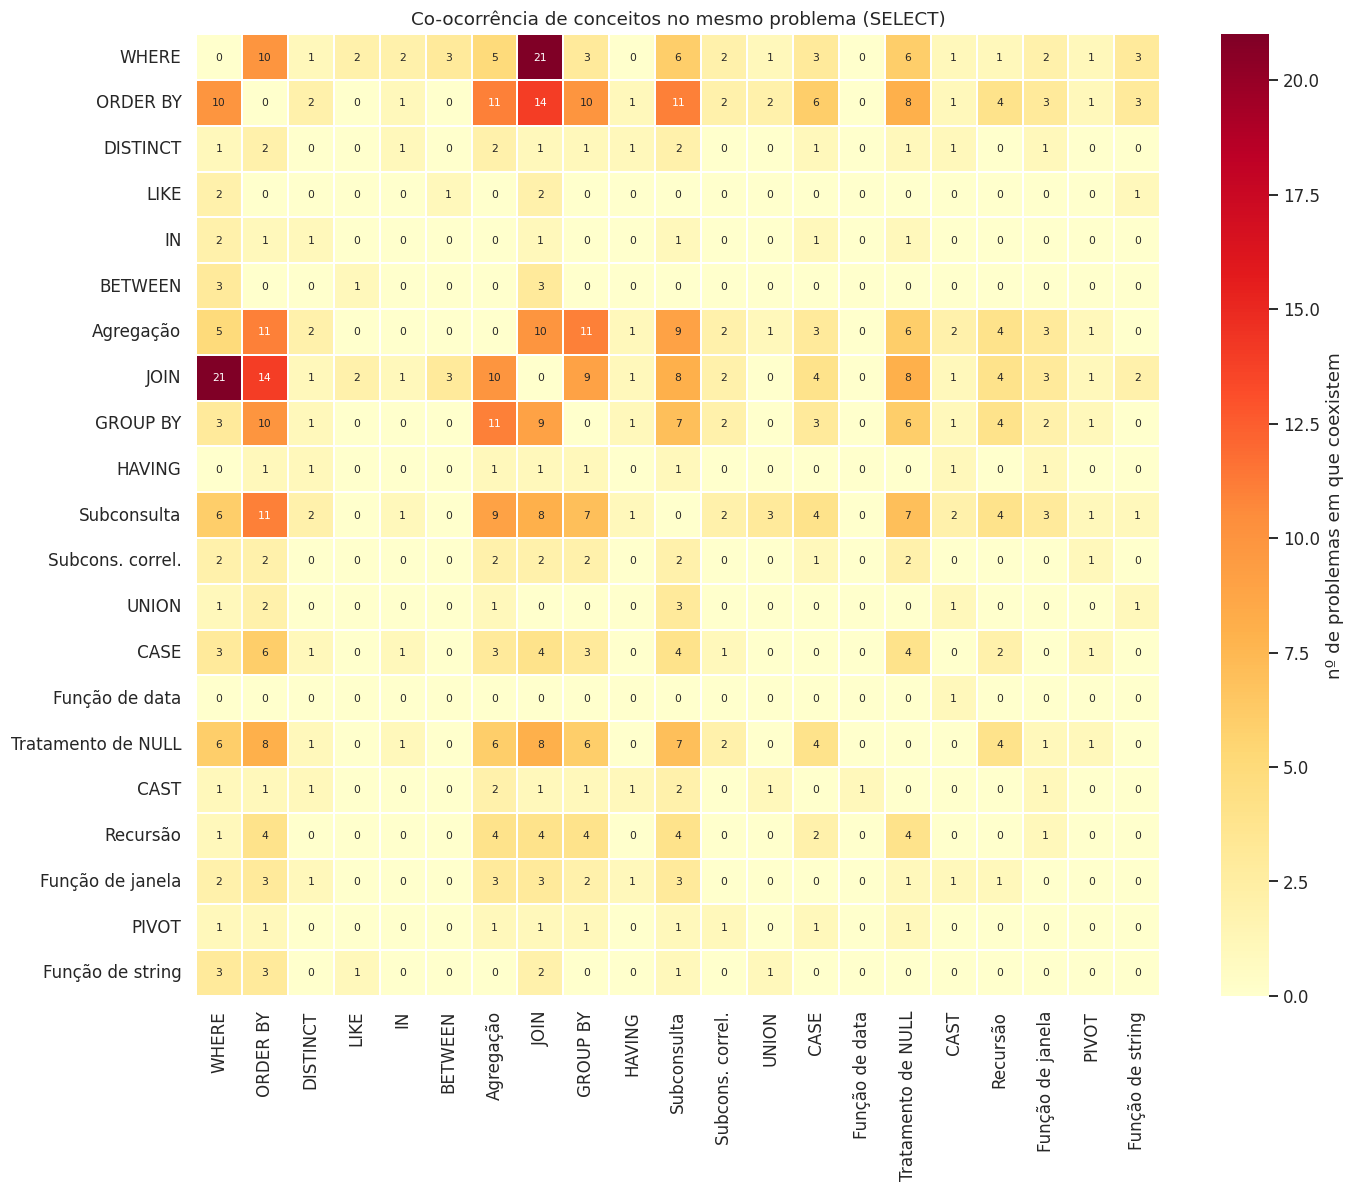

In [13]:
M = df[usa_cols].values
coocc = np.array(M.T @ M, dtype=int)
labels = rotular(usa_cols)
cooc_df = pd.DataFrame(coocc, index=labels, columns=labels)
for lab in labels:
    cooc_df.loc[lab, lab] = 0

plt.figure(figsize=(13, 11))
sns.heatmap(cooc_df, cmap="YlOrRd", annot=True, fmt="d", annot_kws={"size": 7},
            linewidths=0.3, cbar_kws={"label": "nº de problemas em que coexistem"})
plt.title("Co-ocorrência de conceitos no mesmo problema (SELECT)")
plt.tight_layout(); plt.show()

### 4.3 Densidade conceitual — problemas-síntese (Top 15)


,problema_id,titulo,nivel,num_conceitos_total,conceito_primario,conceitos_lista
0,2988,Campeonato Cearense,4,10,Subconsulta correlacionada,"WHERE, ORDER BY, Agregação, JOIN, GROUP BY, Su..."
1,2992,Divisões Com Maiores Médias Salariais,7,9,Recursão,"WHERE, ORDER BY, Agregação, JOIN, GROUP BY, Su..."
2,3492,Ranking turismo CE,1,9,Função de janela,"ORDER BY, DISTINCT, Agregação, JOIN, GROUP BY,..."
3,2991,Estatísticas dos Departamentos,9,8,Recursão,"ORDER BY, Agregação, JOIN, GROUP BY, Subconsul..."
4,2997,Pagamento dos Empregados,9,8,Recursão,"ORDER BY, Agregação, JOIN, GROUP BY, Subconsul..."
5,2999,Maior Sálario da Divisão,5,8,Subconsulta correlacionada,"WHERE, ORDER BY, Agregação, JOIN, GROUP BY, Su..."
6,2989,Departamentos e Divisões,7,7,Recursão,"ORDER BY, Agregação, JOIN, GROUP BY, Subconsul..."
7,3481,Classificando uma Árvore,2,7,Subconsulta,"WHERE, ORDER BY, DISTINCT, IN, Subconsulta, CA..."
8,2998,The Payback,6,6,Função de janela,"WHERE, ORDER BY, Agregação, JOIN, Subconsulta,..."
9,2737,Advogados,6,5,Subconsulta,"WHERE, Agregação, Subconsulta, UNION, CAST"


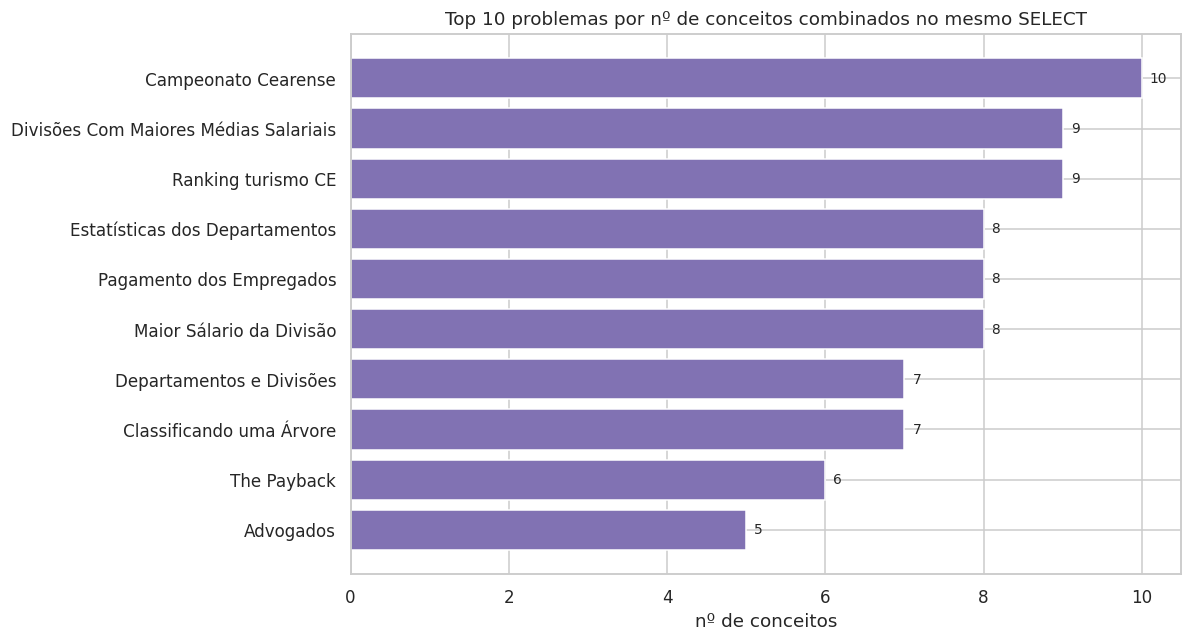

In [14]:
top = df.nlargest(10, "num_conceitos_total")[
    ["problema_id", "titulo", "nivel", "num_conceitos_total", "conceito_primario", "conceitos_lista"]
].reset_index(drop=True)
display(top)

plt.figure(figsize=(11, 6))
d = df.sort_values("num_conceitos_total", ascending=True).tail(10)
plt.barh(d["titulo"], d["num_conceitos_total"], color="#8172B3")
for i, v in enumerate(d["num_conceitos_total"]):
    plt.text(v + 0.1, i, f"{int(v)}", va="center", fontsize=9)
plt.title("Top 10 problemas por nº de conceitos combinados no mesmo SELECT")
plt.xlabel("nº de conceitos"); plt.tight_layout(); plt.show()


### 4.4 Mapa de escolha: conceito primário × faixa de complexidade


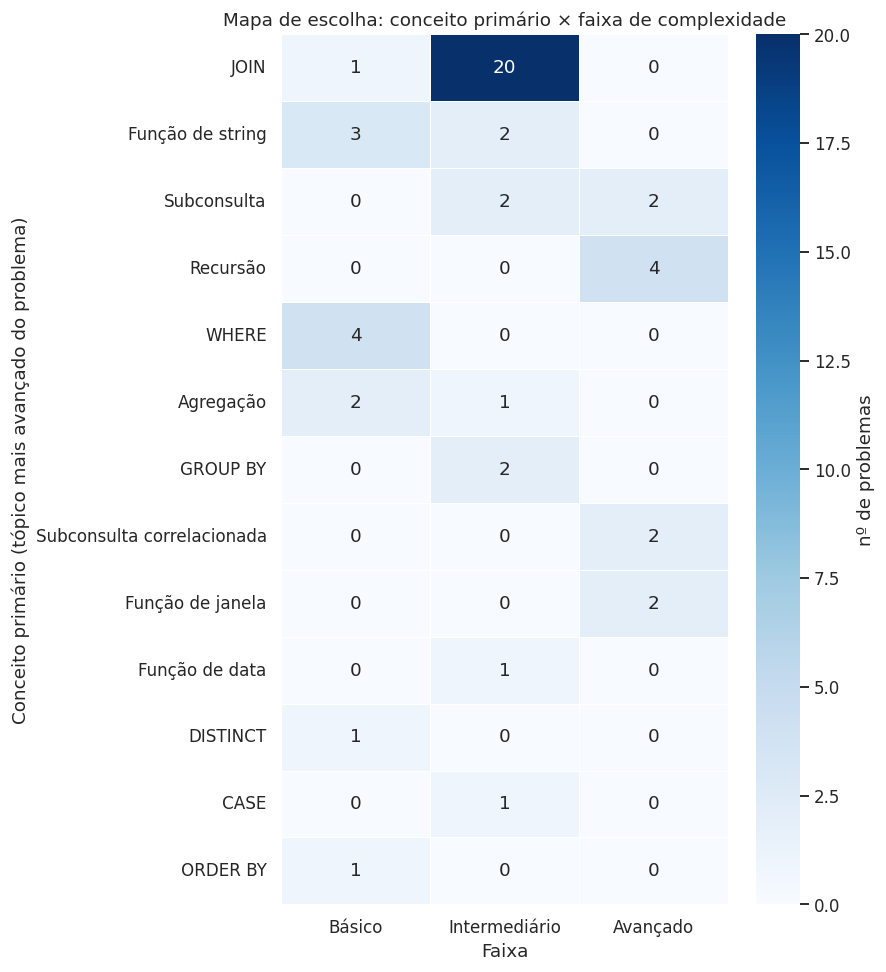

faixa_conceitual,Básico,Intermediário,Avançado
conceito_primario,,,
JOIN,1,20,0
Função de string,3,2,0
Subconsulta,0,2,2
Recursão,0,0,4
WHERE,4,0,0
Agregação,2,1,0
GROUP BY,0,2,0
Subconsulta correlacionada,0,0,2
Função de janela,0,0,2


In [15]:
pivot = pd.crosstab(df["conceito_primario"], df["faixa_conceitual"])
pivot = pivot.reindex(columns=["Básico", "Intermediário", "Avançado"], fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(8, 9))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "nº de problemas"})
plt.title("Mapa de escolha: conceito primário × faixa de complexidade")
plt.ylabel("Conceito primário (tópico mais avançado do problema)"); plt.xlabel("Faixa")
plt.tight_layout(); plt.show()
pivot

## 5. Aprendizado de Máquina I — Clusterização (K-Means)


In [16]:
# Features da clusterização: APENAS o perfil conceitual (as 21 flags usa_*).
# O nível declarado (nivel) NÃO entra na formação dos clusters — ele é usado
# somente A POSTERIORI (Seção 5.2), para comparar os grupos descobertos com a
# dificuldade declarada pela plataforma. Isso evita circularidade, já que a QP2
# justamente avalia se o nível declarado é coerente com a complexidade real.
features = list(usa_cols)  # sem "nivel"
X = df[features].fillna(0).astype(float)
X_scaled = StandardScaler().fit_transform(X)
print("Matriz de features (somente conceitos, sem nível):", X_scaled.shape)


Matriz de features (somente conceitos, sem nível): (51, 21)


### 5.1 Análise de hiperparâmetros — escolha de *k*


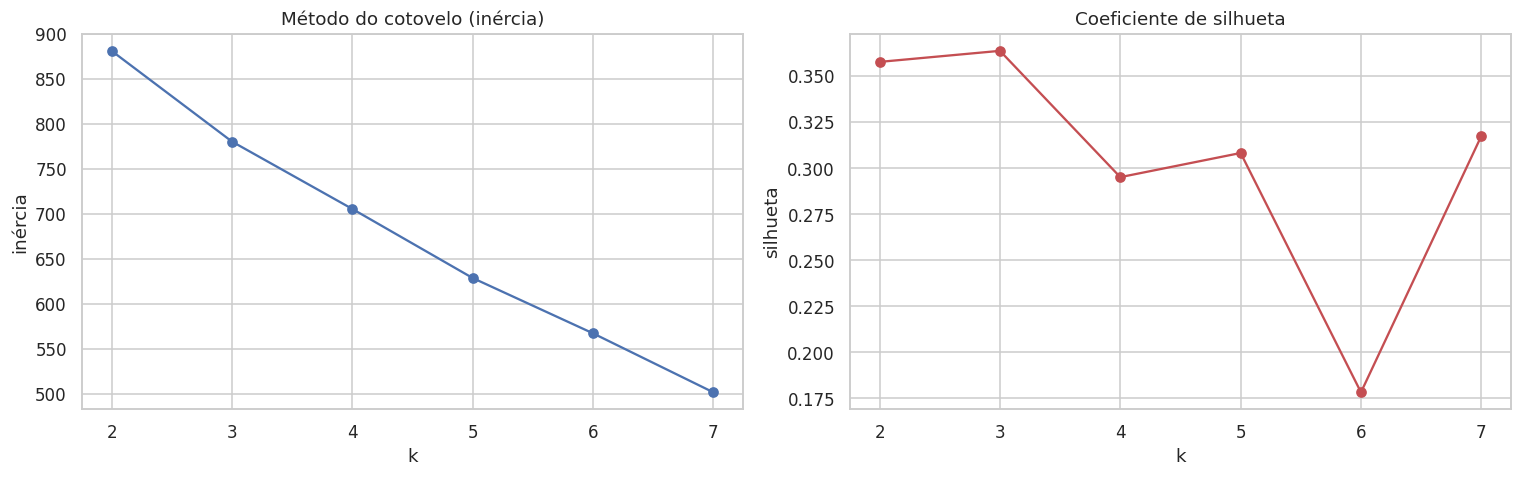

k=2: silhueta=0.358
k=3: silhueta=0.364
k=4: silhueta=0.295
k=5: silhueta=0.308
k=6: silhueta=0.178
k=7: silhueta=0.317

Melhor k pela silhueta: 3


In [17]:
ks = range(2, 8)
inercias, silhuetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(list(ks), inercias, "o-", color="#4C72B0"); ax[0].set_title("Método do cotovelo (inércia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inércia")
ax[1].plot(list(ks), silhuetas, "o-", color="#C44E52"); ax[1].set_title("Coeficiente de silhueta")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhueta")
plt.tight_layout(); plt.show()

for k, s in zip(ks, silhuetas):
    print(f"k={k}: silhueta={s:.3f}")
melhor_k = list(ks)[int(np.argmax(silhuetas))]
print(f"\nMelhor k pela silhueta: {melhor_k}")

### 5.2 Ajuste final e perfil dos clusters


In [18]:
k = 3
km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)

tmp = df.copy(); tmp["_lab"] = km.labels_
ordem_l = tmp.groupby("_lab")["num_conceitos_total"].mean().sort_values().index
remap = {c: i for i, c in enumerate(ordem_l)}
df["cluster_final"] = [remap[l] for l in km.labels_]

perfil = df.groupby("cluster_final").agg(
    n=("problema_id", "count"),
    nivel_medio=("nivel", "mean"),
    conceitos_medio=("num_conceitos_total", "mean"),
    resolvidos_medio=("num_resolvidos", "mean"),
    complexidade_media=("complexidade_tecnica", "mean"),
).round(2)
perfil

,n,nivel_medio,conceitos_medio,resolvidos_medio,complexidade_media
cluster_final,,,,,
0,43,3.30,2.44,12275.16,3.72
1,7,6.14,8.14,1383.57,16.57
2,1,1.00,9.00,50.00,18.00


### 5.3 Visualização dos clusters via PCA (2D)


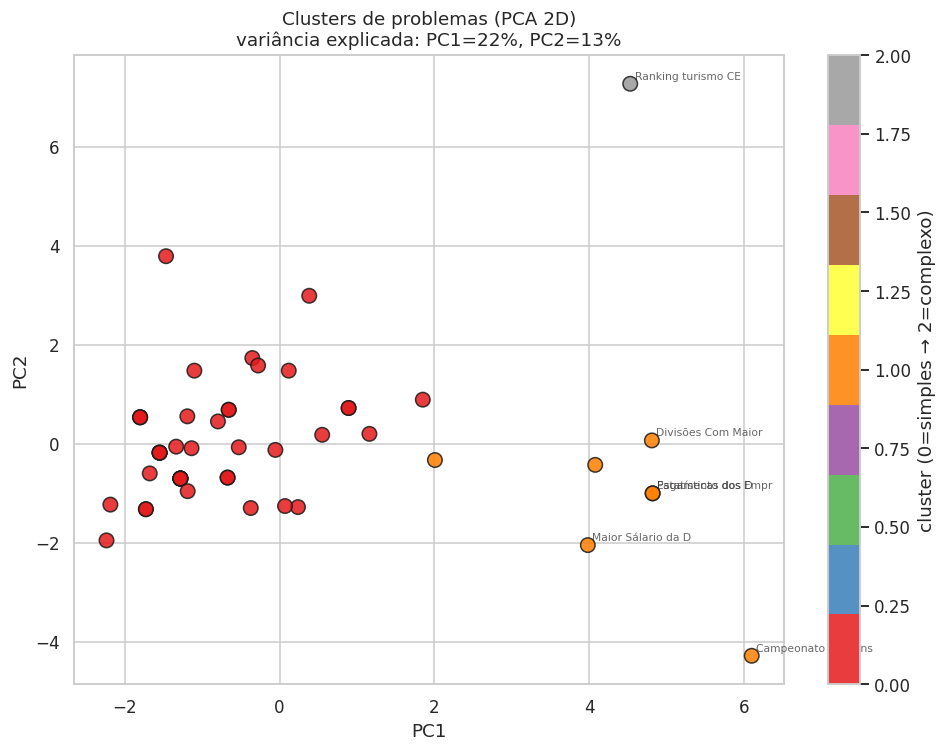

In [19]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_

plt.figure(figsize=(9, 7))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=df["cluster_final"],
                 cmap="Set1", s=90, edgecolor="k", alpha=0.85)
for i, r in df.iterrows():
    if r["num_conceitos_total"] >= 8:
        plt.annotate(str(r["titulo"])[:18], (coords[i, 0], coords[i, 1]),
                     fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")
plt.title(f"Clusters de problemas (PCA 2D)\n"
          f"variância explicada: PC1={var[0]:.0%}, PC2={var[1]:.0%}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar(sc, label="cluster (0=simples → 2=complexo)")
plt.tight_layout(); plt.show()

## 6. Aprendizado de Máquina II — Regras de Associação (Apriori)


### 6.1 Itemsets frequentes e geração das regras


In [20]:
cesta = df[usa_cols].astype(bool)
cesta.columns = rotular(usa_cols)

freq_is = apriori(cesta, min_support=0.12, use_colnames=True, max_len=3)
print(f"Itemsets frequentes (sup≥0.12, até 3 itens): {len(freq_is)}")

regras = association_rules(freq_is, metric="confidence", min_threshold=0.6)
regras = regras[regras["lift"] > 1.2].copy()
regras["n_ant"] = regras["antecedents"].apply(len)
regras["n_con"] = regras["consequents"].apply(len)
regras = regras[(regras["n_ant"] <= 2) & (regras["n_con"] == 1)]
regras = regras.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)

def _fmt(itemset): return " + ".join(sorted(itemset))
regras["Antecedente"] = regras["antecedents"].apply(_fmt)
regras["Consequente"] = regras["consequents"].apply(_fmt)

tabela = regras[["Antecedente", "Consequente", "support", "confidence", "lift"]].round(3)
tabela.columns = ["Antecedente", "Consequente", "Suporte", "Confiança", "Lift"]
print(f"Regras robustas e interpretáveis: {len(tabela)}")
display(tabela.head(15))

Itemsets frequentes (sup≥0.12, até 3 itens): 36
Regras robustas e interpretáveis: 47


,Antecedente,Consequente,Suporte,Confiança,Lift
0,Agregação + ORDER BY,GROUP BY,0.196,0.909,4.215
1,Agregação + JOIN,GROUP BY,0.176,0.900,4.173
2,JOIN + Subconsulta,GROUP BY,0.137,0.875,4.057
3,ORDER BY + Tratamento de NULL,Subconsulta,0.137,0.875,3.719
4,Agregação + Subconsulta,GROUP BY,0.137,0.778,3.606
5,ORDER BY + Subconsulta,Tratamento de NULL,0.137,0.636,3.606
6,Agregação + JOIN,Subconsulta,0.157,0.800,3.400
7,Tratamento de NULL,Subconsulta,0.137,0.778,3.306
8,GROUP BY + JOIN,Subconsulta,0.137,0.778,3.306
9,GROUP BY,Agregação,0.216,1.000,3.188


### 6.2 Visualização — Top 12 regras por lift (Figura 9)


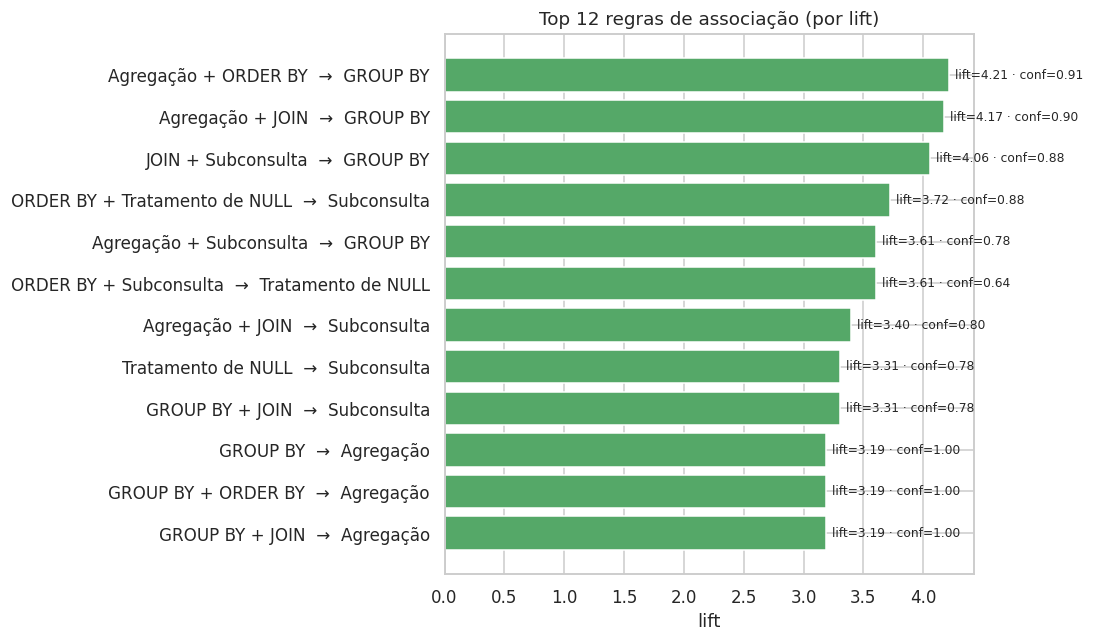

In [21]:
# Figura 9 — apenas o gráfico de lift (Top 12 regras)
top_r = regras.head(12).iloc[::-1]
rot = top_r["Antecedente"] + "  →  " + top_r["Consequente"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rot, top_r["lift"], color="#55A868", edgecolor="white")
for i, (l, c) in enumerate(zip(top_r["lift"], top_r["confidence"])):
    ax.text(l + 0.05, i, f"lift={l:.2f} · conf={c:.2f}", va="center", fontsize=8)
ax.set_xlabel("lift"); ax.set_title("Top 12 regras de associação (por lift)")
plt.tight_layout(); plt.show()


## 7. Respostas às questões de pesquisa


### QP2 — Coerência entre nível declarado e complexidade técnica real


Correlação nível declarado × complexidade técnica (recalculada):
  Pearson  r = 0.527 (p=0.0001)
  Spearman ρ = 0.518 (p=0.0001)


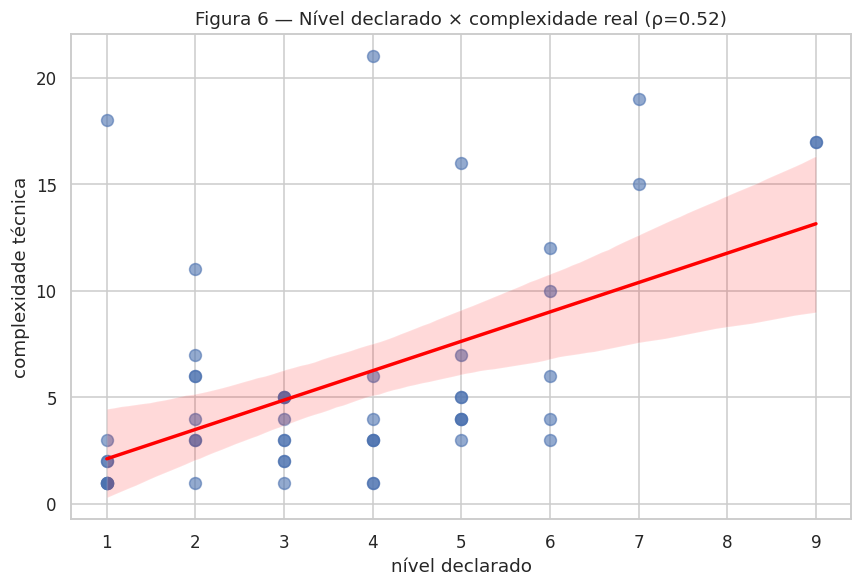

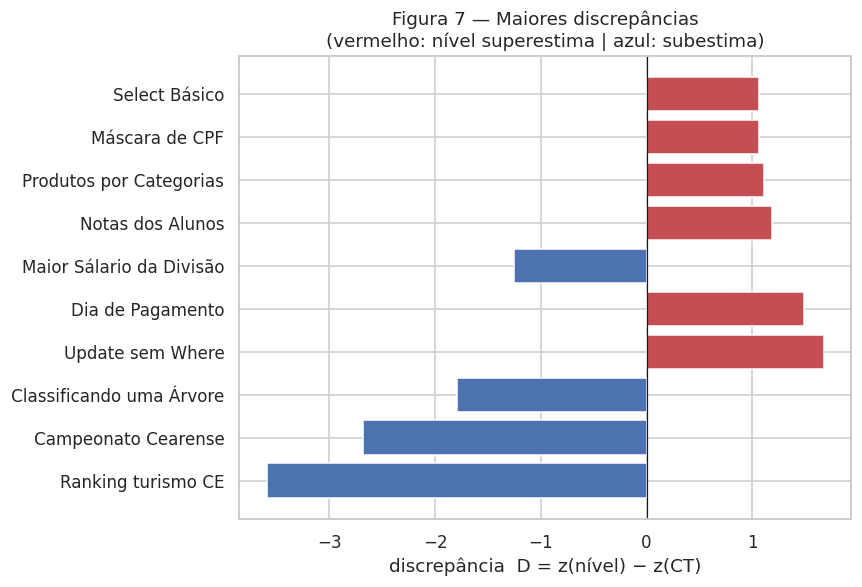

In [22]:
rho, p_s = spearmanr(df["nivel"], df["complexidade_tecnica"])
r, p_p   = pearsonr(df["nivel"], df["complexidade_tecnica"])
print("Correlação nível declarado × complexidade técnica (recalculada):")
print(f"  Pearson  r = {r:.3f} (p={p_p:.4f})")
print(f"  Spearman ρ = {rho:.3f} (p={p_s:.4f})")

# --- Figura 6a: dispersão nível × complexidade técnica ---
fig6a, ax6a = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=df, x="nivel", y="complexidade_tecnica", ax=ax6a,
            scatter_kws={"s": 60, "alpha": .6}, line_kws={"color": "red"})
ax6a.set_title(f"Figura 6 — Nível declarado × complexidade real (ρ={rho:.2f})")
ax6a.set_xlabel("nível declarado"); ax6a.set_ylabel("complexidade técnica")
plt.tight_layout(); plt.show()

# --- Figura 7: maiores discrepâncias  D = z(nível) - z(CT) ---
fig6b, ax6b = plt.subplots(figsize=(8, 5.5))
disc = df.reindex(df["discrepancia_nivel_complexidade"].abs().sort_values(ascending=False).index)
top_disc = disc.head(10)
ax6b.barh(top_disc["titulo"], top_disc["discrepancia_nivel_complexidade"],
          color=["#C44E52" if v > 0 else "#4C72B0" for v in top_disc["discrepancia_nivel_complexidade"]])
ax6b.axvline(0, color="k", lw=.8)
ax6b.set_xlabel("discrepância  D = z(nível) − z(CT)")
ax6b.set_title("Figura 7 — Maiores discrepâncias\n(vermelho: nível superestima | azul: subestima)")
plt.tight_layout(); plt.show()


### QP1 & QP3 — Adequação e cobertura curricular


In [23]:
freq_abs = df[usa_cols].sum()
rasos = freq_abs[freq_abs <= 2]
bem = freq_abs[freq_abs >= 10]
print(f"Total de conceitos anotados: {len(usa_cols)}")
print(f"Conceitos com cobertura RASA (≤2 problemas): {len(rasos)}")
print("  ->", rotular(rasos.index.tolist()))
print(f"Conceitos BEM cobertos (≥10 problemas): {len(bem)}")
print("  ->", rotular(bem.index.tolist()))
print("\nDistribuição por faixa conceitual:")
print(df["faixa_conceitual"].value_counts().reindex(["Básico", "Intermediário", "Avançado"]))

Total de conceitos anotados: 21
Conceitos com cobertura RASA (≤2 problemas): 6
  -> ['LIKE', 'IN', 'HAVING', 'Subcons. correl.', 'Função de data', 'PIVOT']
Conceitos BEM cobertos (≥10 problemas): 6
  -> ['WHERE', 'ORDER BY', 'Agregação', 'JOIN', 'GROUP BY', 'Subconsulta']

Distribuição por faixa conceitual:
faixa_conceitual
Básico           12
Intermediário    29
Avançado         10
Name: count, dtype: int64
